Dataset shape: (19311, 12)

Class distribution in train:
hit
0    13764
1      965
Name: count, dtype: int64

Class distribution in test:
hit
0    3446
1     244
Name: count, dtype: int64

Shapes:
X_test: (3690, 46) y_test: (3690,)

===== MODEL PERFORMANCE =====
Accuracy: 0.9395663956639566
Precision: 0.5251798561151079
Recall: 0.8975409836065574
F1 Score: 0.6626323751891074
ROC-AUC: 0.9792477379332656

Confusion Matrix:
[[3248  198]
 [  25  219]]


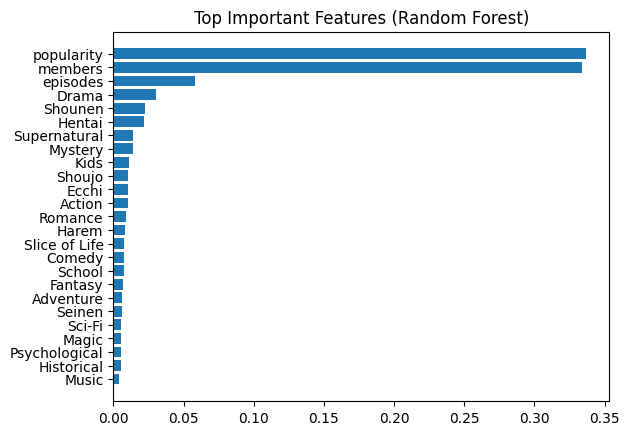

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import ast

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import MultiLabelBinarizer
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, roc_auc_score, confusion_matrix
)

# ---------------------------
# 1. Load dataset (safe mode)
# ---------------------------
df = pd.read_csv(
    "./dataset/animes.csv",
    on_bad_lines='skip',
    encoding='utf-8'
)

print("Dataset shape:", df.shape)

# ---------------------------
# 2. Basic cleaning
# ---------------------------
df = df.dropna(subset=['score'])

drop_cols = ['uid', 'title', 'synopsis', 'img_url', 'link', 'aired', 'ranked']
df = df.drop(columns=drop_cols, errors='ignore')

# ---------------------------
# 3. Safe genre conversion
# ---------------------------
def safe_parse(x):
    try:
        return ast.literal_eval(x)
    except:
        return []

df['genre'] = df['genre'].apply(safe_parse)

# ---------------------------
# 4. Genre encoding
# ---------------------------
mlb = MultiLabelBinarizer()

genre_encoded = pd.DataFrame(
    mlb.fit_transform(df['genre']),
    columns=mlb.classes_,
    index=df.index
)

df = df.drop('genre', axis=1)
df = pd.concat([df, genre_encoded], axis=1)

# ---------------------------
# 5. Convert to classification
# ---------------------------
df['hit'] = (df['score'] >= 8).astype(int)

# ---------------------------
# 6. Features & target
# ---------------------------
X = df.drop(['score', 'hit'], axis=1)
y = df['hit']

# ---------------------------
# 7. Train-test split (important stratify)
# ---------------------------
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

# ---------------------------
# 8. Safe NaN handling
# ---------------------------
train_mask = ~X_train.isna().any(axis=1)
X_train = X_train[train_mask]
y_train = y_train[train_mask]

test_mask = ~X_test.isna().any(axis=1)
X_test = X_test[test_mask]
y_test = y_test[test_mask]

# ---------------------------
# 9. Debug check (IMPORTANT)
# ---------------------------
print("\nClass distribution in train:")
print(y_train.value_counts())

print("\nClass distribution in test:")
print(y_test.value_counts())

print("\nShapes:")
print("X_test:", X_test.shape, "y_test:", y_test.shape)

# ---------------------------
# 10. Model (Random Forest Classifier)
# ---------------------------
model = RandomForestClassifier(
    n_estimators=300,
    max_depth=15,
    min_samples_split=5,
    min_samples_leaf=2,
    class_weight="balanced",
    random_state=42,
    n_jobs=-1
)

model.fit(X_train, y_train)

# ---------------------------
# 11. Predictions
# ---------------------------
y_pred = model.predict(X_test)
y_prob = model.predict_proba(X_test)[:, 1]

# ---------------------------
# 12. Metrics (SAFE PRINT)
# ---------------------------
print("\n===== MODEL PERFORMANCE =====")

print("Accuracy:", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred, zero_division=0))
print("Recall:", recall_score(y_test, y_pred, zero_division=0))
print("F1 Score:", f1_score(y_test, y_pred, zero_division=0))

if len(np.unique(y_test)) > 1:
    print("ROC-AUC:", roc_auc_score(y_test, y_prob))
else:
    print("ROC-AUC: Not enough classes in test set")

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred))

# ---------------------------
# 13. Feature importance
# ---------------------------
importance = model.feature_importances_
features = X.columns

top_idx = importance.argsort()[-25:]

plt.figure()
plt.barh(range(len(top_idx)), importance[top_idx])
plt.yticks(range(len(top_idx)), [features[i] for i in top_idx])
plt.title("Top Important Features (Random Forest)")
plt.show()